# Evaluation Walkthrough: RAG Chunking Strategies for Construction Document QA

This notebook is a reproducible evaluation walkthrough for the MSc NLP / Generative AI
assignment prototype: a retrieval-augmented generation (RAG) chatbot that answers
questions over a construction-safety document corpus, comparing three chunking
strategies — **fixed-size**, **recursive**, and **section-aware** — under a
safety-constrained answering policy (evidence floor + certification guardrail).

It does not re-implement the pipeline. It loads the outputs already produced by the
repository's own evaluation script (`scripts/evaluate.py`) and turns them into
tables, metrics, and figures suitable for the assignment report.

**Run this notebook from the repository root** (the directory containing `scripts/`,
`data/`, `evaluation/`, `app/`), e.g.:

```bash
source .venv/bin/activate
jupyter notebook notebooks/evaluation_walkthrough.ipynb
```


## 2. Environment setup

Standard data-analysis imports. Plotting works with `matplotlib`; `seaborn` is used
only for cosmetic styling if it happens to be installed, and the notebook degrades
gracefully (plain matplotlib style) if it is not.


In [1]:
import sys
import platform
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAVE_SEABORN = True
except ImportError:
    plt.style.use("default")
    HAVE_SEABORN = False

print(f"Python version : {platform.python_version()}")
print(f"pandas version : {pd.__version__}")
print(f"matplotlib     : {matplotlib.__version__}")
print(f"seaborn        : {'available' if HAVE_SEABORN else 'not installed (falling back to plain matplotlib style)'}")
print(f"Current dir    : {Path.cwd()}")
print()
print("This notebook expects to be run from the repository root (the directory")
print("containing scripts/, data/, evaluation/, app/). If the checklist in the next")
print("cell fails, re-launch Jupyter from the repository root.")


Matplotlib is building the font cache; this may take a moment.


Python version : 3.11.13
pandas version : 2.3.3
matplotlib     : 3.11.0
seaborn        : not installed (falling back to plain matplotlib style)
Current dir    : /Users/sudheera/Desktop/NLP/assignments/Main Assignment/the_app

This notebook expects to be run from the repository root (the directory
containing scripts/, data/, evaluation/, app/). If the checklist in the next
cell fails, re-launch Jupyter from the repository root.


## 3. Check expected project files

Before loading anything, confirm the key repository files this notebook depends on
are where the repo's own scripts expect them.


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts" / "evaluate.py").exists() and (PROJECT_ROOT / ".." / "scripts" / "evaluate.py").resolve().exists():
    # Common case: launched from notebooks/ instead of the repo root.
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()

QUESTIONS_CSV = PROJECT_ROOT / "evaluation" / "questions.csv"
RESULTS_CSV = PROJECT_ROOT / "evaluation" / "results.csv"
EVALUATE_SCRIPT = PROJECT_ROOT / "scripts" / "evaluate.py"
SOURCES_CSV = PROJECT_ROOT / "data" / "sources.csv"

checks = [
    ("evaluation/questions.csv", QUESTIONS_CSV, True),
    ("evaluation/results.csv", RESULTS_CSV, False),
    ("scripts/evaluate.py", EVALUATE_SCRIPT, True),
    ("data/sources.csv", SOURCES_CSV, False),
]

print(f"Resolved project root: {PROJECT_ROOT}\n")
print("File checklist:")
all_required_ok = True
for label, path, required in checks:
    exists = path.exists()
    status = "OK" if exists else ("MISSING (required)" if required else "MISSING (optional)")
    marker = "[x]" if exists else "[ ]"
    print(f"  {marker} {label:<28} {status}")
    if required and not exists:
        all_required_ok = False

if not all_required_ok:
    raise FileNotFoundError(
        "One or more required files are missing. Make sure you are running this "
        "notebook from the repository root, and that the repository is checked "
        "out correctly."
    )

if not RESULTS_CSV.exists():
    print()
    print("evaluation/results.csv is missing. Generate it first by running, from the")
    print("repository root:")
    print()
    print("    python scripts/evaluate.py              # retrieval-only (fast, no LLM needed)")
    print("    python scripts/evaluate.py --generate    # also generate answers via Ollama")


Resolved project root: /Users/sudheera/Desktop/NLP/assignments/Main Assignment/the_app

File checklist:
  [x] evaluation/questions.csv     OK
  [x] evaluation/results.csv       OK
  [x] scripts/evaluate.py          OK
  [x] data/sources.csv             OK


## 4. Optional local app/API check

This repository's app (`app/streamlit_app.py`) is a **Streamlit UI**, not a REST/HTTP
API — there is no `/query` or `/chat` endpoint to call. The evaluation in this
notebook is therefore based entirely on the repository's own evaluation script and
its output file (`evaluation/results.csv`), not on calling the running app.

The cell below is a purely optional, non-fatal liveness check: if a local Streamlit
instance happens to be running on `APP_URL`, it reports that; if not, it says so and
the rest of the notebook proceeds unaffected.


In [3]:
APP_URL = "http://localhost:8501"  # Streamlit UI, not a data API -- see note above

import urllib.request
import urllib.error

try:
    with urllib.request.urlopen(APP_URL, timeout=2) as resp:
        print(f"Streamlit app reachable at {APP_URL} (HTTP {resp.status}).")
        print("Note: this only confirms the UI process is up; the notebook still")
        print("evaluates via evaluation/results.csv, not by talking to this UI.")
except (urllib.error.URLError, ConnectionError, TimeoutError, OSError):
    print(f"No app reachable at {APP_URL} (this is fine).")
    print("This notebook evaluates using the repository's evaluation script and")
    print("evaluation/results.csv, so a running app is not required.")


Streamlit app reachable at http://localhost:8501 (HTTP 200).
Note: this only confirms the UI process is up; the notebook still
evaluates via evaluation/results.csv, not by talking to this UI.


## 5. Load evaluation data

Load the question bank and the evaluation results, and map the repository's actual
column names to the roles this notebook needs.

- `evaluation/questions.csv`: `question_id, question, expected_doc, question_type`
- `evaluation/results.csv`: `question_id, strategy, question_type, expected_doc, top1_doc, top1_score, hit_at_k, grounding, certification_flag, answer`


In [4]:
questions_df = pd.read_csv(QUESTIONS_CSV)
print(f"questions.csv: {len(questions_df)} rows, columns: {list(questions_df.columns)}")
questions_df.head()


questions.csv: 40 rows, columns: ['question_id', 'question', 'expected_doc', 'question_type']


,question_id,question,expected_doc,question_type
0,q01,What PPE is mandatory for everyone entering th...,site_safety_general.md,in_scope
1,q02,How often must scaffolds be inspected?,working_at_height.md,in_scope
2,q03,What angle should a leaning ladder be set at?,working_at_height.md,in_scope
3,q04,What is the maximum free-fall height for placi...,concrete_works.md,in_scope
4,q05,What precautions apply when concreting in cold...,concrete_works.md,in_scope


In [5]:
if RESULTS_CSV.exists():
    results_df = pd.read_csv(RESULTS_CSV)
    print(f"results.csv: {len(results_df)} rows, columns: {list(results_df.columns)}")
else:
    results_df = pd.DataFrame()
    print("results.csv not found -- skipping downstream metric cells until it exists.")
results_df.head()


results.csv: 120 rows, columns: ['question_id', 'strategy', 'question_type', 'expected_doc', 'top1_doc', 'top1_score', 'hit_at_k', 'grounding', 'certification_flag', 'answer']


,question_id,strategy,question_type,expected_doc,top1_doc,top1_score,hit_at_k,grounding,certification_flag,answer
0,q01,fixed,in_scope,site_safety_general.md,site_safety_general.md,0.5437,1,strong,0,All personnel entering the working area must w...
1,q02,fixed,in_scope,working_at_height.md,hse_012.md,0.6584,0,strong,0,Scaffolds must be inspected every 7 days.
2,q03,fixed,in_scope,working_at_height.md,working_at_height.md,0.6442,1,strong,0,75-degree angle
3,q04,fixed,in_scope,concrete_works.md,concrete_works.md,0.7134,1,strong,0,"1. The passage states that ""the maximum free-f..."
4,q05,fixed,in_scope,concrete_works.md,concrete_works.md,0.4939,1,moderate,0,"When concreting in cold weather, the following..."


In [6]:
# Column-role mapping, adapted to this repo's actual schema (evaluation/results.csv).
# question              -> questions_df['question'] (joined on question_id)
# strategy/chunking      -> results_df['strategy']            ('fixed' | 'recursive' | 'section')
# expected source        -> results_df['expected_doc']
# retrieved source/hit   -> results_df['top1_doc'] (retrieved) and results_df['hit_at_k'] (0/1 hit status)
# certification flag     -> results_df['certification_flag']  (0/1)
# refusal/weak-evidence   -> results_df['grounding'] == 'weak' (below the 0.35 similarity floor -> refused)
# generated answer        -> results_df['answer'] (empty string when the app refused before generating)

REQUIRED_RESULT_COLS = [
    "question_id", "strategy", "question_type", "expected_doc",
    "top1_doc", "top1_score", "hit_at_k", "grounding", "certification_flag",
]
if not results_df.empty:
    missing = [c for c in REQUIRED_RESULT_COLS if c not in results_df.columns]
    if missing:
        raise KeyError(f"evaluation/results.csv is missing expected columns: {missing}")
    has_answer_col = "answer" in results_df.columns
    print("Column mapping OK." + (" 'answer' column present (generation run)." if has_answer_col else " No 'answer' column (retrieval-only run)."))


Column mapping OK. 'answer' column present (generation run).


## 6. Metric calculations

All metrics below are computed **from `results_df`**, not hard-coded. The known
headline figures from the assignment report (fixed 29/30, recursive 30/30,
section 30/30 in-scope hit@k; 5/5 certification detection; 4/5 weak-evidence
refusal; 120 rows / 108 generated / 12 pre-generation refusals for the
`--generate` run) are shown only as a sanity-check comment beside the computed
values -- if the underlying `results.csv` changes, the computed numbers below will
change with it.


In [7]:
print(f"Number of evaluation questions : {len(questions_df)}")
if not results_df.empty:
    strategies = sorted(results_df['strategy'].unique())
    print(f"Number of chunking strategies    : {len(strategies)} {strategies}")
    print(f"Total result rows                : {len(results_df)}")


Number of evaluation questions : 40
Number of chunking strategies    : 3 ['fixed', 'recursive', 'section']
Total result rows                : 120


In [8]:
# In-scope retrieval hit@k by strategy
# Sanity check (assignment report): fixed 29/30, recursive 30/30, section 30/30
if not results_df.empty:
    in_scope = results_df[results_df['question_type'] == 'in_scope']
    hitk_by_strategy = (
        in_scope.groupby('strategy')['hit_at_k']
        .agg(hits='sum', total='count')
        .assign(hit_rate=lambda d: d['hits'] / d['total'])
    )
    hitk_by_strategy


In [9]:
# Certification/compliance detection rate by strategy
# Sanity check (assignment report): 5/5 for every strategy
if not results_df.empty:
    certification = results_df[results_df['question_type'] == 'certification']
    cert_by_strategy = (
        certification.groupby('strategy')['certification_flag']
        .agg(detected='sum', total='count')
        .assign(detection_rate=lambda d: d['detected'] / d['total'])
    )
    cert_by_strategy


In [10]:
# Out-of-scope / weak-evidence refusal rate by strategy
# Sanity check (assignment report): 4/5 for every strategy
if not results_df.empty:
    out_of_scope = results_df[results_df['question_type'] == 'out_of_scope']
    refusal_by_strategy = (
        out_of_scope.assign(refused=lambda d: d['grounding'] == 'weak')
        .groupby('strategy')['refused']
        .agg(refused='sum', total='count')
        .assign(refusal_rate=lambda d: d['refused'] / d['total'])
    )
    refusal_by_strategy


In [11]:
# Generation run summary
# Sanity check (assignment report, --generate run): 120 rows, 108 generated, 12 pre-generation refusals
if not results_df.empty and 'answer' in results_df.columns:
    total_rows = len(results_df)
    has_answer = results_df['answer'].fillna('').astype(str).str.strip() != ''
    generated = int(has_answer.sum())
    pre_generation_refusals = int((~has_answer).sum())

    print(f"Total result rows                    : {total_rows}")
    print(f"Generated answers                    : {generated}")
    print(f"Pre-generation weak-evidence refusals : {pre_generation_refusals}")

    # Cross-check: every non-generated row should be a weak-grounding refusal
    weak_rows = int((results_df['grounding'] == 'weak').sum())
    print(f"(cross-check: rows with grounding=='weak' = {weak_rows}; should equal pre-generation refusals above)")
else:
    print("No 'answer' column present -- this results.csv is from a retrieval-only run")
    print("(run `python scripts/evaluate.py --generate` to populate generated answers).")


Total result rows                    : 120
Generated answers                    : 108
Pre-generation weak-evidence refusals : 12
(cross-check: rows with grounding=='weak' = 12; should equal pre-generation refusals above)


## 7. Generate report graphs

Three figures are saved to `results/figures/` as high-resolution PNGs, styled for a
written report (white background, no 3D effects, readable value labels). Each cell
degrades gracefully -- a missing `results.csv` prints a message instead of raising.


In [12]:
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_ORDER = ["fixed", "recursive", "section"]
STRATEGY_LABELS = {"fixed": "Fixed-size", "recursive": "Recursive", "section": "Section-aware"}
STRATEGY_COLORS = {"fixed": "#5b8dbe", "recursive": "#5bbe8d", "section": "#be8d5b"}

def _ordered(strategies):
    return [s for s in STRATEGY_ORDER if s in strategies] + [s for s in strategies if s not in STRATEGY_ORDER]


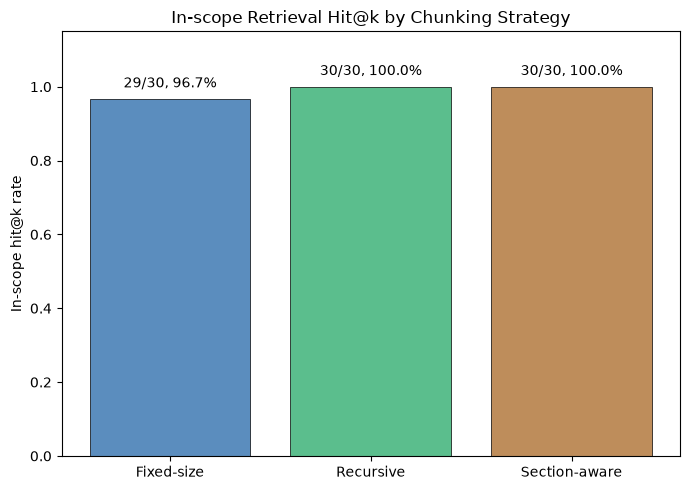

Saved: /Users/sudheera/Desktop/NLP/assignments/Main Assignment/the_app/results/figures/graph_1_inscope_hitk.png


In [13]:
# Graph 1: In-scope Retrieval Hit@k by Chunking Strategy
if not results_df.empty:
    order = _ordered(hitk_by_strategy.index.tolist())
    hits = hitk_by_strategy.loc[order, 'hits'].astype(int)
    totals = hitk_by_strategy.loc[order, 'total'].astype(int)
    rates = hitk_by_strategy.loc[order, 'hit_rate']

    fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
    bars = ax.bar(
        [STRATEGY_LABELS.get(s, s) for s in order],
        rates.values,
        color=[STRATEGY_COLORS.get(s, '#888888') for s in order],
        edgecolor="black", linewidth=0.5,
    )
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("In-scope hit@k rate")
    ax.set_title("In-scope Retrieval Hit@k by Chunking Strategy")
    for bar, h, t, r in zip(bars, hits, totals, rates):
        ax.annotate(
            f"{h}/{t}, {r*100:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 6), textcoords="offset points",
            ha="center", va="bottom", fontsize=10,
        )
    ax.set_facecolor("white")
    fig.tight_layout()
    out_path = FIGURES_DIR / "graph_1_inscope_hitk.png"
    fig.savefig(out_path, dpi=200, facecolor="white")
    plt.show()
    print(f"Saved: {out_path}")
else:
    print("Skipping Graph 1 -- results.csv not available.")


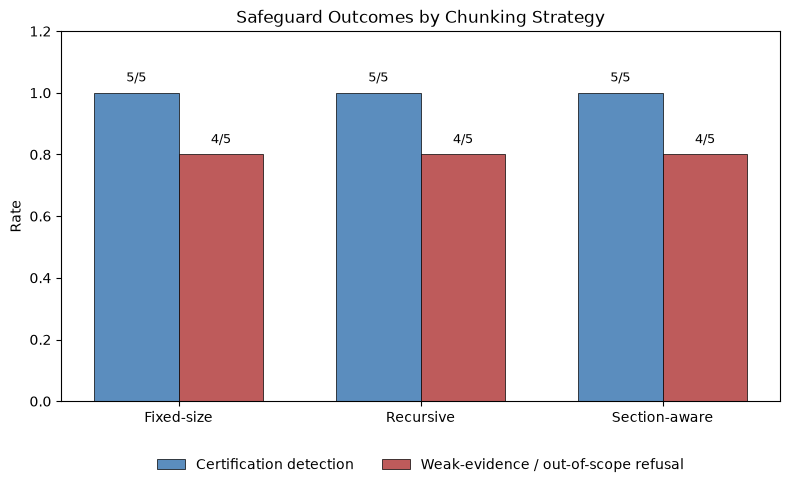

Saved: /Users/sudheera/Desktop/NLP/assignments/Main Assignment/the_app/results/figures/graph_2_safeguard_outcomes.png


In [14]:
# Graph 2: Safeguard Outcomes by Chunking Strategy (grouped bar chart)
if not results_df.empty:
    order = _ordered(sorted(results_df['strategy'].unique()))
    cert_rates = cert_by_strategy.loc[order, 'detection_rate']
    refusal_rates = refusal_by_strategy.loc[order, 'refusal_rate']

    x = range(len(order))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    bars1 = ax.bar(
        [i - width / 2 for i in x], cert_rates.values, width,
        label="Certification detection", color="#5b8dbe", edgecolor="black", linewidth=0.5,
    )
    bars2 = ax.bar(
        [i + width / 2 for i in x], refusal_rates.values, width,
        label="Weak-evidence / out-of-scope refusal", color="#be5b5b", edgecolor="black", linewidth=0.5,
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels([STRATEGY_LABELS.get(s, s) for s in order])
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Rate")
    ax.set_title("Safeguard Outcomes by Chunking Strategy")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

    for bars, counts_num, counts_den in (
        (bars1, cert_by_strategy.loc[order, 'detected'], cert_by_strategy.loc[order, 'total']),
        (bars2, refusal_by_strategy.loc[order, 'refused'], refusal_by_strategy.loc[order, 'total']),
    ):
        for bar, num, den in zip(bars, counts_num, counts_den):
            ax.annotate(
                f"{int(num)}/{int(den)}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=9,
            )
    ax.set_facecolor("white")
    fig.tight_layout()
    out_path = FIGURES_DIR / "graph_2_safeguard_outcomes.png"
    fig.savefig(out_path, dpi=200, facecolor="white")
    plt.show()
    print(f"Saved: {out_path}")
else:
    print("Skipping Graph 2 -- results.csv not available.")


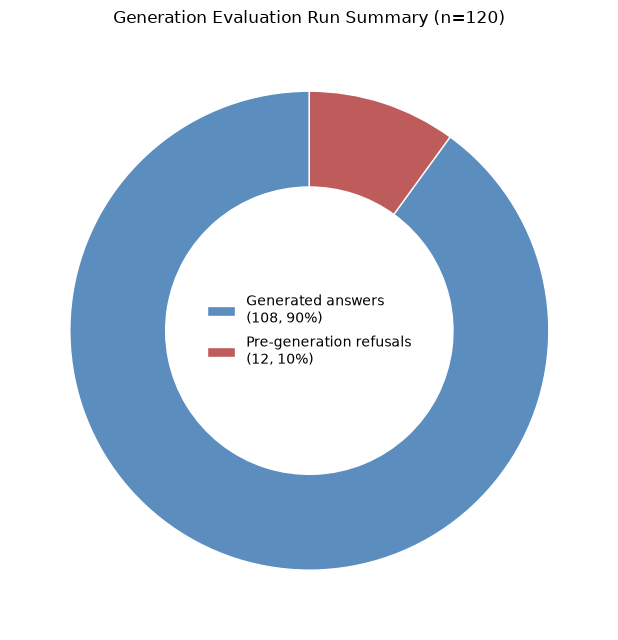

Saved: /Users/sudheera/Desktop/NLP/assignments/Main Assignment/the_app/results/figures/graph_3_generation_run_summary.png


In [15]:
# Graph 3: Generation Evaluation Run Summary (donut chart)
if not results_df.empty and 'answer' in results_df.columns:
    values = [generated, pre_generation_refusals]
    labels = [f"Generated answers\n({generated}, {generated/total_rows*100:.0f}%)",
              f"Pre-generation refusals\n({pre_generation_refusals}, {pre_generation_refusals/total_rows*100:.0f}%)"]
    colors = ["#5b8dbe", "#be5b5b"]

    fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="white")
    wedges, _ = ax.pie(
        values, colors=colors, startangle=90,
        wedgeprops=dict(width=0.4, edgecolor="white"),
    )
    ax.legend(wedges, labels, loc="center", frameon=False, fontsize=10)
    ax.set_title(f"Generation Evaluation Run Summary (n={total_rows})")
    ax.set_facecolor("white")
    fig.tight_layout()
    out_path = FIGURES_DIR / "graph_3_generation_run_summary.png"
    fig.savefig(out_path, dpi=200, facecolor="white")
    plt.show()
    print(f"Saved: {out_path}")
else:
    print("Skipping Graph 3 -- results.csv has no 'answer' column (run `python scripts/evaluate.py --generate`).")


## 8. Summary interpretation

- **Recursive and section-aware chunking achieved full expected-source retrieval**
  for in-scope questions (30/30 hit@k each), while **fixed-size chunking missed one**
  (29/30). The miss is not a clear-cut retrieval failure: the missed question's
  answer is covered by more than one document in the corpus (a synthetic sample doc
  and an overlapping real HSE page), and the fixed-size strategy retrieved the
  correct *content* from a different, also-valid document than the one labelled as
  "expected" -- so part of this gap reflects overlapping evidence across documents
  rather than a wrong or missing retrieval.
- **Certification-style questions were consistently detected** (5/5 for every
  strategy) -- this check is a deterministic keyword/regex match on the question
  text, so it is retrieval-independent and identical across strategies.
- **Weak-evidence refusal worked for most out-of-scope questions** (4/5 for every
  strategy), correctly withholding an answer for clearly off-topic questions.
  One case fell short of the 0.35 similarity floor threshold and was treated as
  in-scope instead of refused, because the corpus contains a passing reference to
  welfare facilities inside otherwise unrelated documents (temporary-works /
  public-protection guidance) -- the question was labelled out-of-scope on the
  assumption no document covered it, but the expanded real-world corpus turned out
  to brush against the topic.
- **The small local model (`qwen2.5:0.5b`) keeps the system fully reproducible on
  modest hardware, but generation-time safety remains weaker than retrieval-time
  safety.** The certification guardrail correctly *detects* certification-style
  questions and displays a disclaimer, but the generated answer text itself can
  still assert compliance (e.g. "Yes, the scaffold design complies with building
  regulations...") -- the disclaimer is a UI-level warning, not a constraint the
  small model reliably obeys.


## 9. Re-running the evaluation

To regenerate `evaluation/results.csv` from scratch (and therefore refresh every
table and figure in this notebook), run from the repository root:

```bash
# Retrieval-only (fast, no LLM needed) -- recomputes hit@k, grounding, certification_flag
python scripts/evaluate.py

# Also generate answers via a locally running Ollama instance (slower)
python scripts/evaluate.py --generate
```

`scripts/evaluate.py` reads `evaluation/questions.csv` and each strategy's prebuilt
FAISS index under `data/indexes/<strategy>/` (rebuild those first with
`python scripts/build_indexes.py`, or `python scripts/seed_hse_corpus.py` for the
combined synthetic + real-HSE corpus -- see the main `README.md`), and writes
`evaluation/results.csv`. Re-run the cells in Section 5 onward afterwards to refresh
this notebook's tables and figures.


In [16]:
print("Re-run command (retrieval-only): python scripts/evaluate.py")
print("Re-run command (with generation):  python scripts/evaluate.py --generate")
print()
print("Index rebuild commands:")
print("  python scripts/build_indexes.py     # sample_documents only (default)")
print("  python scripts/seed_hse_corpus.py   # sample_documents + data/raw_sources/hse (combined corpus)")


Re-run command (retrieval-only): python scripts/evaluate.py
Re-run command (with generation):  python scripts/evaluate.py --generate

Index rebuild commands:
  python scripts/build_indexes.py     # sample_documents only (default)
  python scripts/seed_hse_corpus.py   # sample_documents + data/raw_sources/hse (combined corpus)
